# NASA C-MAPSS Visualization Notebook

This notebook provides an exploratory visualization workflow for the NASA C-MAPSS turbofan run-to-failure datasets FD001–FD004.

It is designed to help you inspect:
- dataset size and trajectory lengths
- operating-condition structure
- train/test/RUL setup
- sensor trends over life
- healthy vs late-life differences
- near-constant / low-information sensors
- correlation structure
- degradation signatures by Remaining Useful Life (RUL) stage

The dataset structure follows the uploaded README: each row is one engine-cycle snapshot, with 26 variables consisting of unit number, cycle, 3 operational settings, and 21 sensor measurements. FD001–FD004 differ by number of operating conditions and fault modes.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('../../data/CMAPSSData/')  # change if needed
DEFAULT_FD = 'FD001'  # choose: FD001, FD002, FD003, FD004
SAMPLE_ENGINES = 4
TOP_SENSOR_COUNT = 8


In [2]:
COLUMNS = (
    ['unit', 'cycle'] +
    [f'op_setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)
OP_COLS = [f'op_setting_{i}' for i in range(1, 4)]
SENSOR_COLS = [f'sensor_{i}' for i in range(1, 22)]

FD_META = {
    'FD001': {'conditions': 1, 'fault_modes': 1, 'fault_desc': 'HPC degradation'},
    'FD002': {'conditions': 6, 'fault_modes': 1, 'fault_desc': 'HPC degradation'},
    'FD003': {'conditions': 1, 'fault_modes': 2, 'fault_desc': 'HPC + fan degradation'},
    'FD004': {'conditions': 6, 'fault_modes': 2, 'fault_desc': 'HPC + fan degradation'},
}


def load_cmapss_split(fd='FD001', data_dir=DATA_DIR):
    train_path = data_dir / f'train_{fd}.txt'
    test_path = data_dir / f'test_{fd}.txt'
    rul_path = data_dir / f'RUL_{fd}.txt'

    if not train_path.exists():
        raise FileNotFoundError(f'Missing file: {train_path}')
    if not test_path.exists():
        raise FileNotFoundError(f'Missing file: {test_path}')
    if not rul_path.exists():
        raise FileNotFoundError(f'Missing file: {rul_path}')

    def _read_txt(path):
        df = pd.read_csv(
            path,
            sep=r'\s+',
            header=None,
            engine='python'
        )
        # Standard C-MAPSS text files can contain 26 real columns and sometimes extra empty columns.
        df = df.iloc[:, :26].copy()
        df.columns = COLUMNS
        return df

    train_df = _read_txt(train_path)
    test_df = _read_txt(test_path)
    rul_df = pd.read_csv(rul_path, sep=r'\s+', header=None, engine='python').dropna(axis=1, how='all')
    rul_df.columns = ['rul']
    rul_df['unit'] = np.arange(1, len(rul_df) + 1)

    return train_df, test_df, rul_df


def add_train_rul(train_df):
    max_cycle = train_df.groupby('unit')['cycle'].max().rename('max_cycle')
    out = train_df.merge(max_cycle, on='unit', how='left')
    out['rul'] = out['max_cycle'] - out['cycle']
    return out


def add_test_rul_proxy(test_df, rul_df):
    last_cycle = test_df.groupby('unit')['cycle'].max().rename('last_cycle')
    merged = test_df.merge(last_cycle, on='unit', how='left').merge(rul_df, on='unit', how='left')
    merged['rul_at_cycle'] = (merged['last_cycle'] - merged['cycle']) + merged['rul']
    return merged


def dataset_overview(train_df, test_df, rul_df, fd='FD001'):
    train_lengths = train_df.groupby('unit')['cycle'].max()
    test_lengths = test_df.groupby('unit')['cycle'].max()
    meta = FD_META.get(fd, {})
    return pd.DataFrame([
        {
            'dataset': fd,
            'train_engines': train_df['unit'].nunique(),
            'test_engines': test_df['unit'].nunique(),
            'train_rows': len(train_df),
            'test_rows': len(test_df),
            'rul_labels': len(rul_df),
            'conditions': meta.get('conditions'),
            'fault_modes': meta.get('fault_modes'),
            'fault_description': meta.get('fault_desc'),
            'avg_train_cycles': round(train_lengths.mean(), 2),
            'avg_test_cycles': round(test_lengths.mean(), 2),
            'max_train_cycles': int(train_lengths.max()),
            'max_test_cycles': int(test_lengths.max()),
        }
    ])


def summarize_sensors(train_rul_df):
    rows = []
    for col in SENSOR_COLS:
        s = train_rul_df[col]
        rows.append({
            'sensor': col,
            'mean': s.mean(),
            'std': s.std(),
            'min': s.min(),
            'max': s.max(),
            'missing_ratio': s.isna().mean(),
            'nunique': s.nunique(),
            'corr_with_rul': train_rul_df[[col, 'rul']].corr().iloc[0, 1],
        })
    out = pd.DataFrame(rows)
    out['abs_corr_with_rul'] = out['corr_with_rul'].abs()
    out['near_constant'] = (out['std'] < 1e-6) | (out['nunique'] <= 2)
    return out.sort_values('abs_corr_with_rul', ascending=False)


def minmax_scale_per_column(df, cols):
    out = df.copy()
    for col in cols:
        s = out[col]
        denom = s.max() - s.min()
        out[col] = 0.0 if denom == 0 else (s - s.min()) / denom
    return out


def zscore_per_column(df, cols):
    out = df.copy()
    for col in cols:
        s = out[col]
        std = s.std()
        out[col] = 0.0 if std == 0 else (s - s.mean()) / std
    return out


def sample_units(df, n=4):
    units = sorted(df['unit'].unique())
    if len(units) <= n:
        return units
    idx = np.linspace(0, len(units) - 1, n).round().astype(int)
    return [units[i] for i in idx]


In [3]:
FD = DEFAULT_FD
train_df, test_df, rul_df = load_cmapss_split(FD, DATA_DIR)
train_rul_df = add_train_rul(train_df)
test_rul_df = add_test_rul_proxy(test_df, rul_df)

print('Loaded:', FD)
display(dataset_overview(train_df, test_df, rul_df, FD))
print('Train shape:', train_df.shape, '| Test shape:', test_df.shape, '| RUL labels:', rul_df.shape)


Loaded: FD001


,dataset,train_engines,test_engines,train_rows,test_rows,rul_labels,conditions,fault_modes,fault_description,avg_train_cycles,avg_test_cycles,max_train_cycles,max_test_cycles
0,FD001,100,100,20631,13096,100,1,1,HPC degradation,206.31,130.96,362,303


Train shape: (20631, 26) | Test shape: (13096, 26) | RUL labels: (100, 2)


## 1) Trajectory length overview

These plots help you inspect how long engines run before failure in training and how early the test trajectories are truncated.

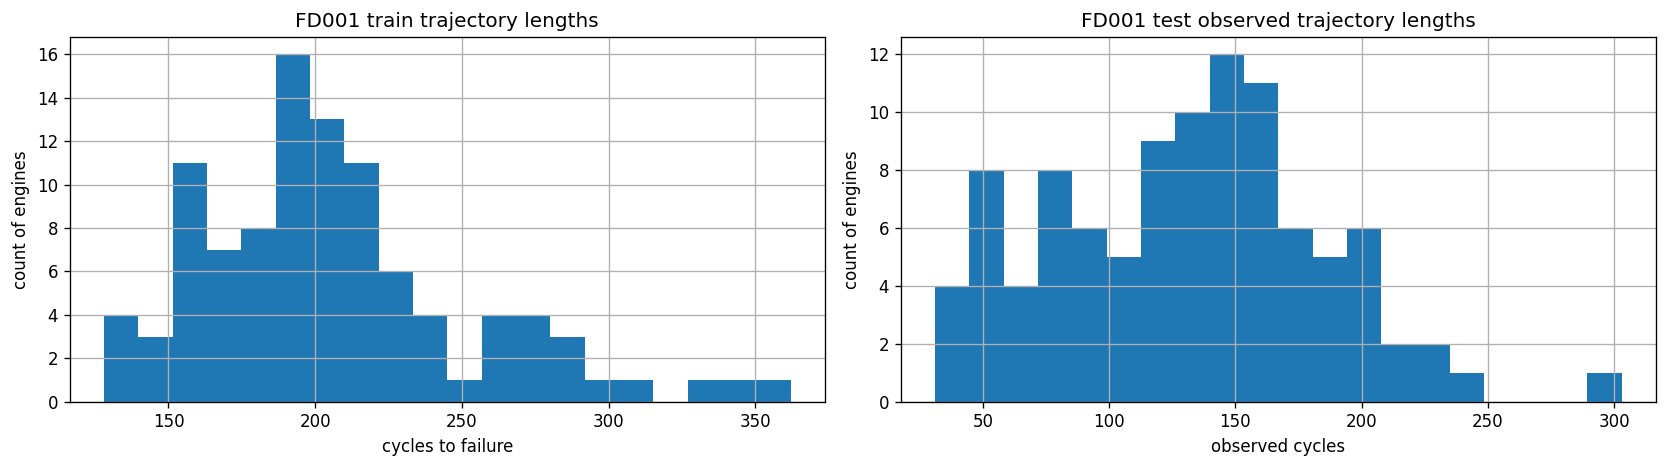

,train_cycles,test_cycles
count,100.000000,100.000000
mean,206.310000,130.960000
std,46.342749,53.593479
min,128.000000,31.000000
25%,177.000000,88.750000
50%,199.000000,133.500000
75%,229.250000,164.250000
max,362.000000,303.000000


In [4]:
train_lengths = train_df.groupby('unit')['cycle'].max()
test_lengths = test_df.groupby('unit')['cycle'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_lengths, bins=20)
axes[0].set_title(f'{FD} train trajectory lengths')
axes[0].set_xlabel('cycles to failure')
axes[0].set_ylabel('count of engines')

axes[1].hist(test_lengths, bins=20)
axes[1].set_title(f'{FD} test observed trajectory lengths')
axes[1].set_xlabel('observed cycles')
axes[1].set_ylabel('count of engines')
plt.tight_layout()
plt.show()

length_summary = pd.DataFrame({
    'train_cycles': train_lengths.describe(),
    'test_cycles': test_lengths.describe(),
})
display(length_summary)


## 2) Operating-condition structure

FD001 and FD003 use one operating condition, while FD002 and FD004 have six operating conditions. The scatter plots below make condition clusters visible.

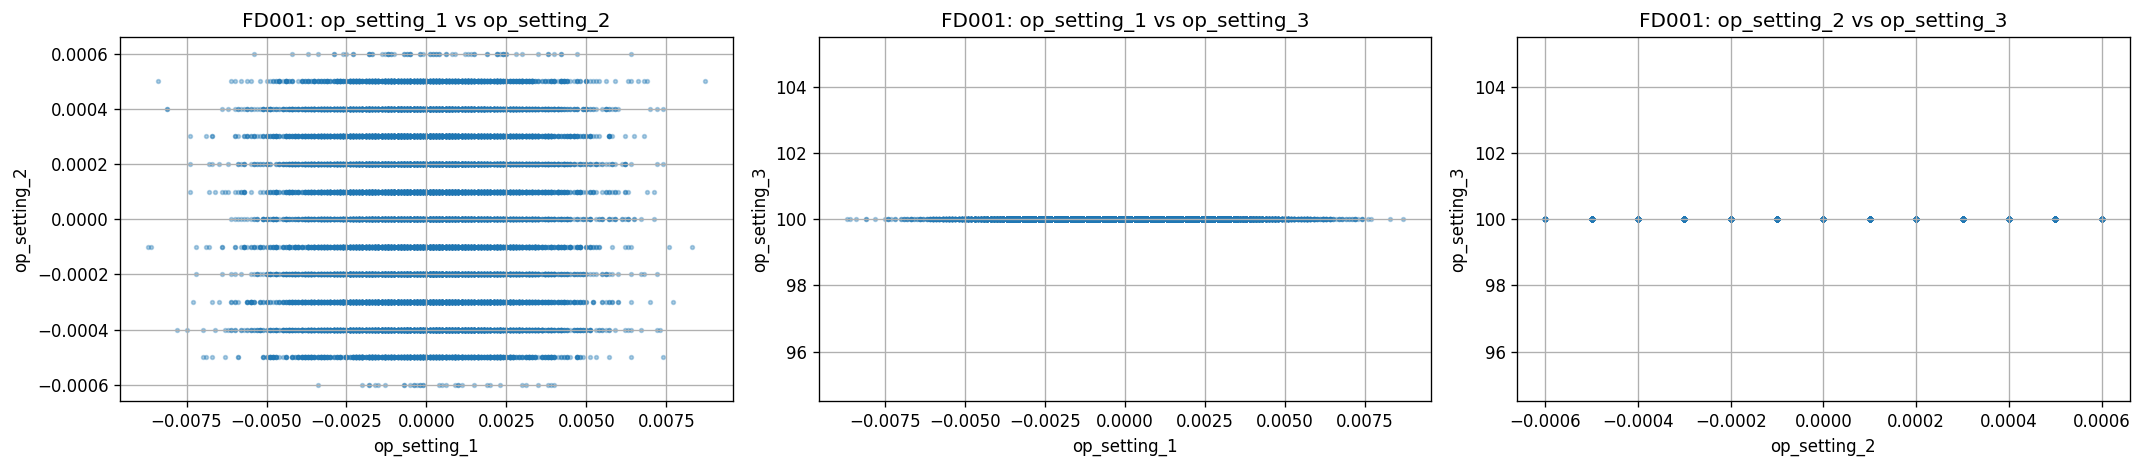

op_setting_1 approx unique values: 19
op_setting_2 approx unique values: 3
op_setting_3 approx unique values: 1


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_pairs = [('op_setting_1', 'op_setting_2'), ('op_setting_1', 'op_setting_3'), ('op_setting_2', 'op_setting_3')]
for ax, (x, y) in zip(axes, plot_pairs):
    ax.scatter(train_df[x], train_df[y], s=5, alpha=0.35)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{FD}: {x} vs {y}')
plt.tight_layout()
plt.show()

for col in OP_COLS:
    vals = train_df[col].round(3)
    print(col, 'approx unique values:', vals.nunique())


## 3) Sensor summary table

This helps identify:
- sensors strongly related to degradation / RUL
- near-constant sensors
- weak / noisy sensors

In [6]:
sensor_summary = summarize_sensors(train_rul_df)
display(sensor_summary.head(15))
print('Near-constant sensors:', sensor_summary.loc[sensor_summary['near_constant'], 'sensor'].tolist())


,sensor,mean,std,min,max,missing_ratio,nunique,corr_with_rul,abs_corr_with_rul,near_constant
10,sensor_11,47.541168,0.267087,46.8500,48.5300,0.0,159,-0.696228,0.696228,False
3,sensor_4,1408.933782,9.000605,1382.2500,1441.4900,0.0,4051,-0.678948,0.678948,False
11,sensor_12,521.413470,0.737553,518.6900,523.3800,0.0,427,0.671983,0.671983,False
6,sensor_7,553.367711,0.885092,549.8500,556.0600,0.0,513,0.657223,0.657223,False
14,sensor_15,8.442146,0.037505,8.3249,8.5848,0.0,1918,-0.642667,0.642667,False
20,sensor_21,23.289705,0.108251,22.8942,23.6184,0.0,4745,0.635662,0.635662,False
19,sensor_20,38.816271,0.180746,38.1400,39.4300,0.0,120,0.629428,0.629428,False
1,sensor_2,642.680934,0.500053,641.2100,644.5300,0.0,310,-0.606484,0.606484,False
16,sensor_17,393.210654,1.548763,388.0000,400.0000,0.0,13,-0.606154,0.606154,False
2,sensor_3,1590.523119,6.131150,1571.0400,1616.9100,0.0,3012,-0.584520,0.584520,False


Near-constant sensors: ['sensor_6', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


## 4) Sample engine trajectories

These plots show full life trajectories for a few engines. It is useful for visually separating gradual degradation from operating-condition jumps.

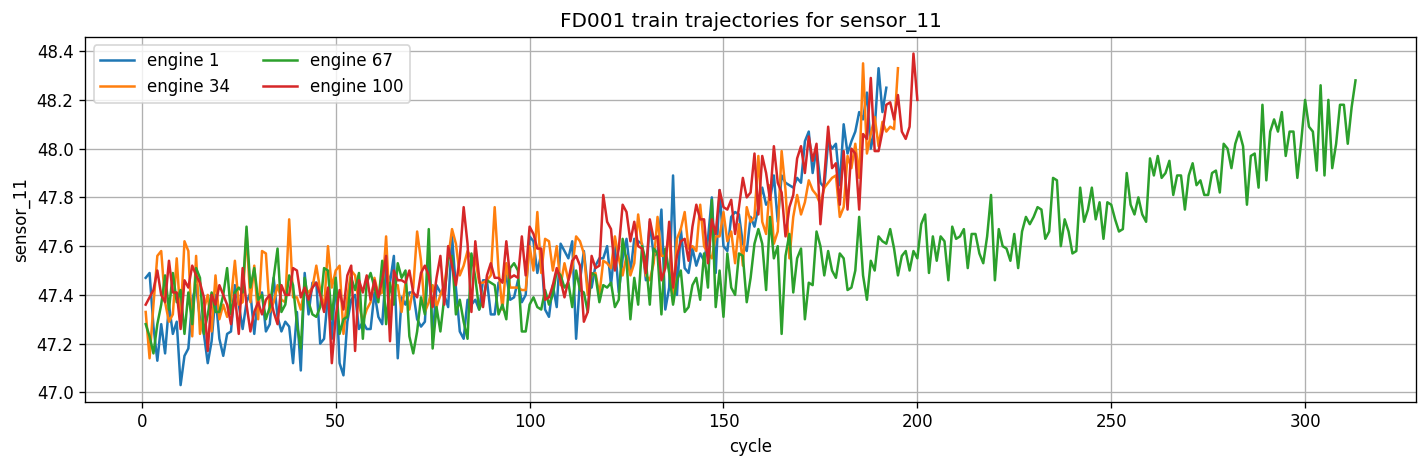

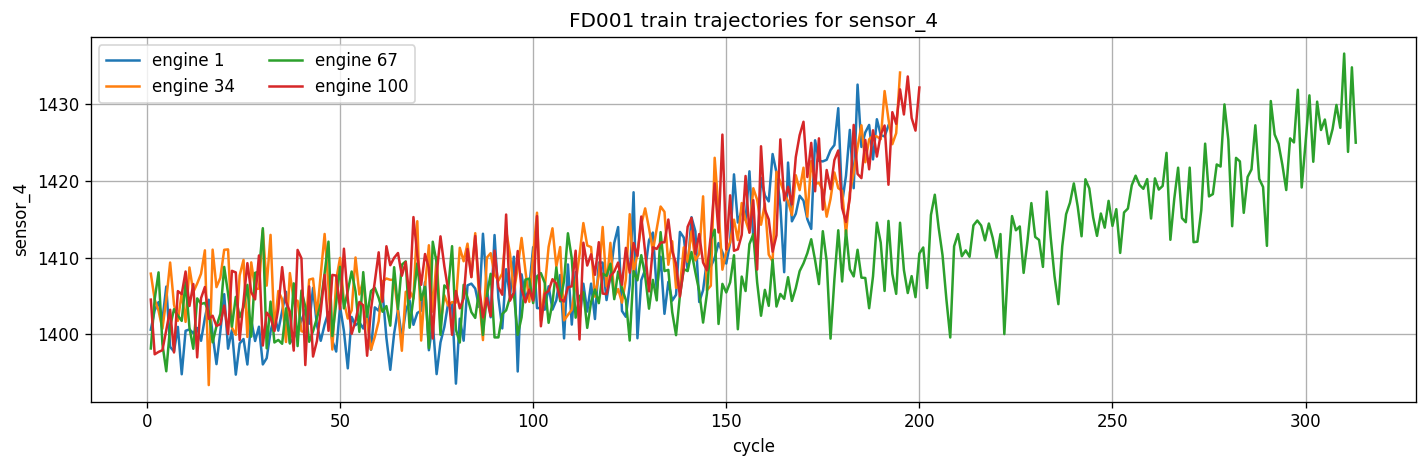

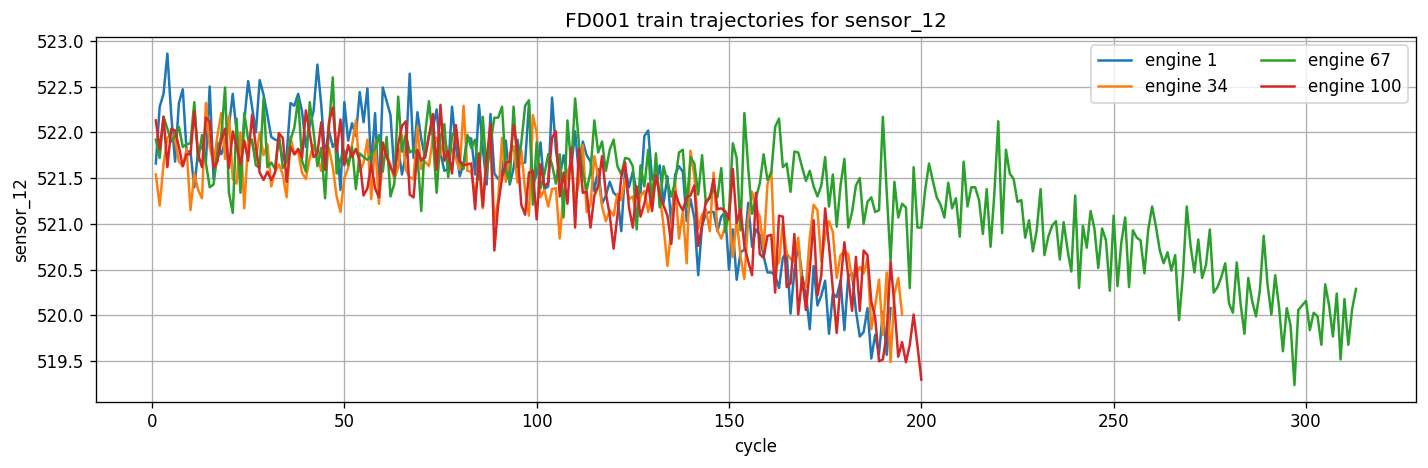

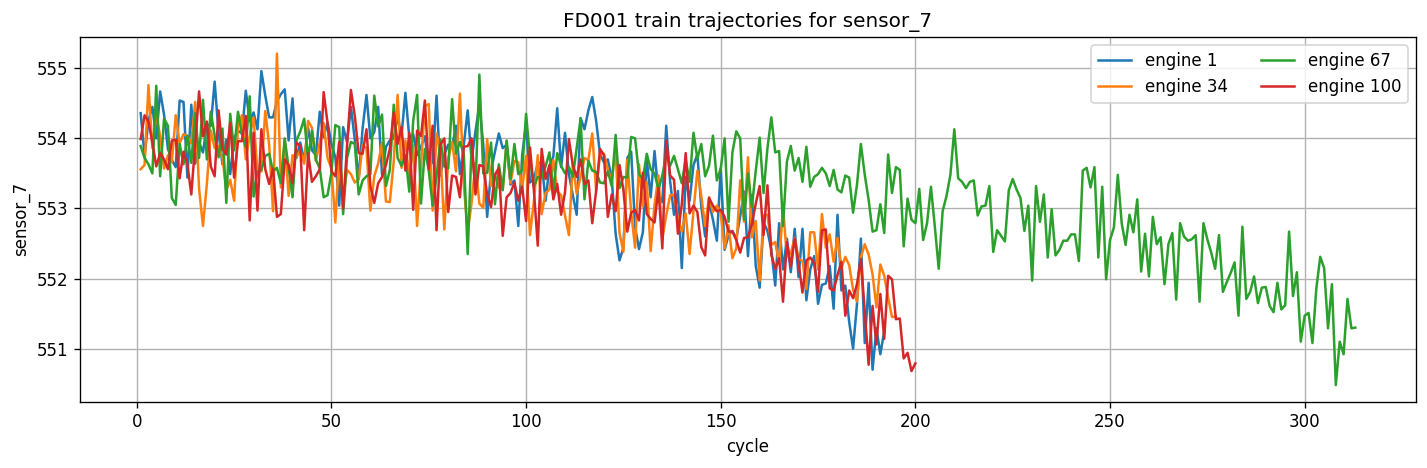

In [7]:
top_sensors = sensor_summary.head(TOP_SENSOR_COUNT)['sensor'].tolist()
units = sample_units(train_rul_df, SAMPLE_ENGINES)

for sensor in top_sensors[:4]:
    plt.figure(figsize=(12, 4))
    for unit in units:
        sub = train_rul_df[train_rul_df['unit'] == unit]
        plt.plot(sub['cycle'], sub[sensor], label=f'engine {unit}')
    plt.title(f'{FD} train trajectories for {sensor}')
    plt.xlabel('cycle')
    plt.ylabel(sensor)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


## 5) Degradation trends against RUL

To compare engines of different lengths, we aggregate by RUL instead of raw cycle count.

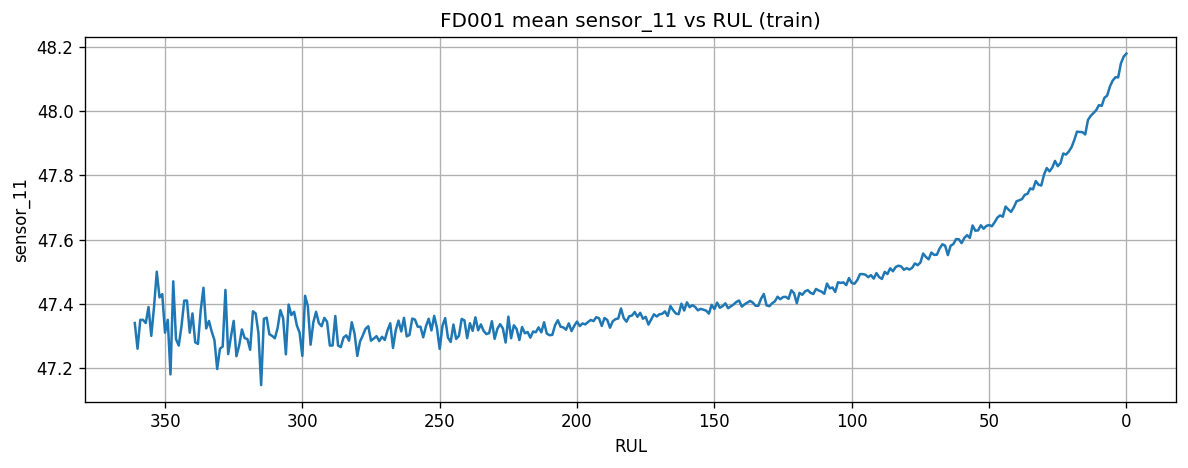

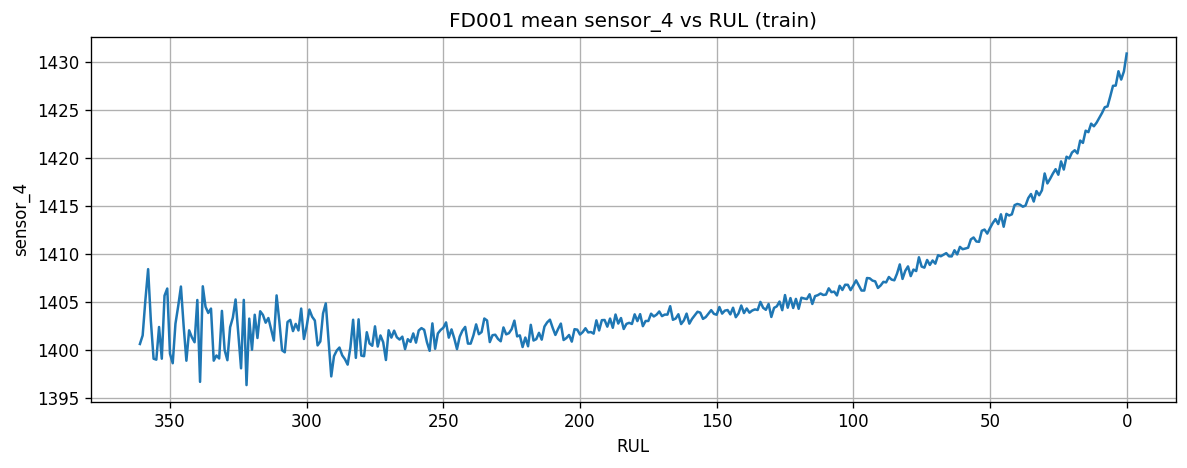

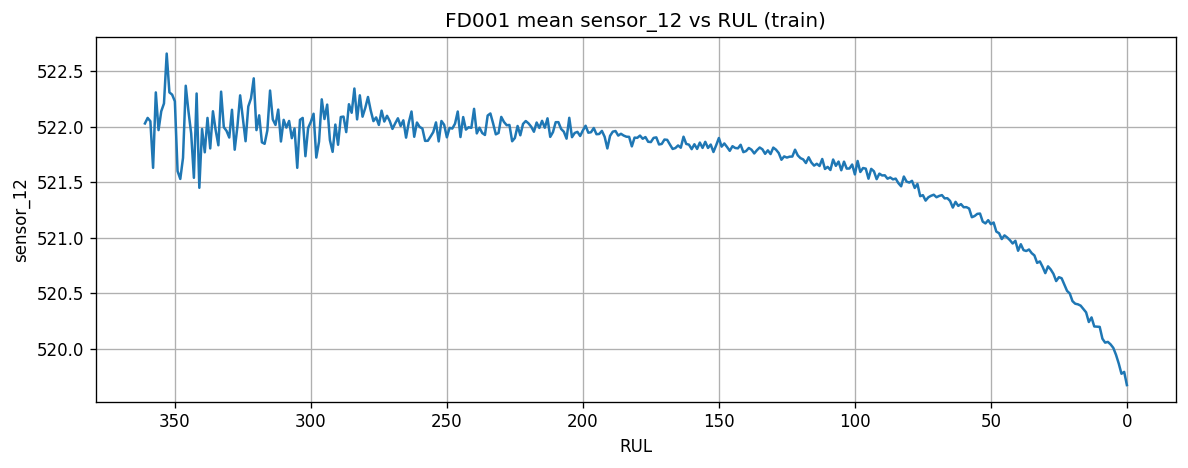

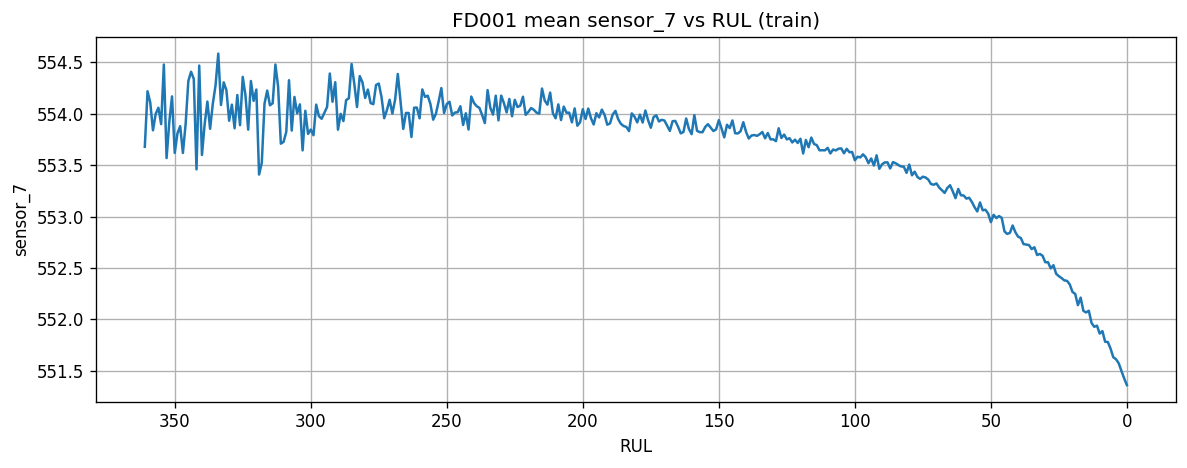

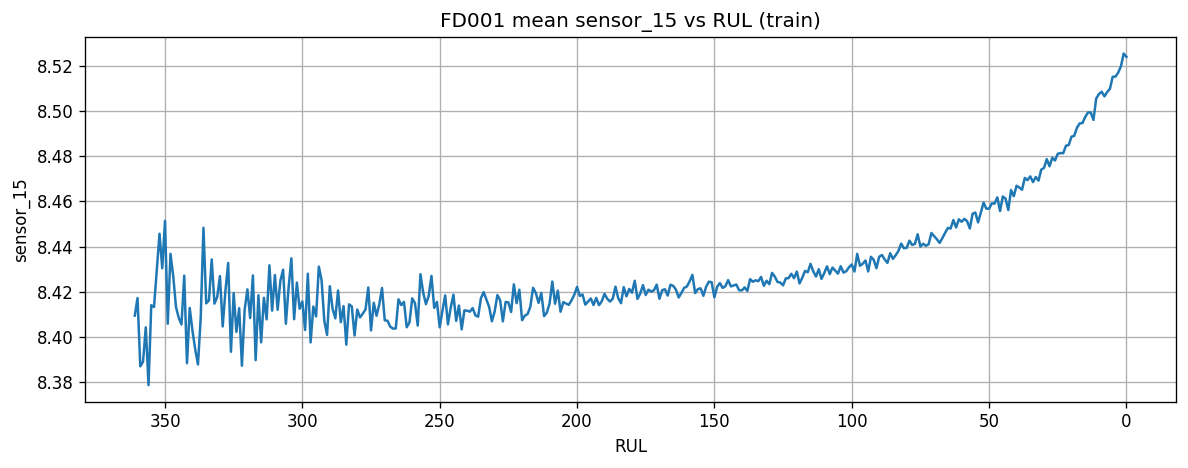

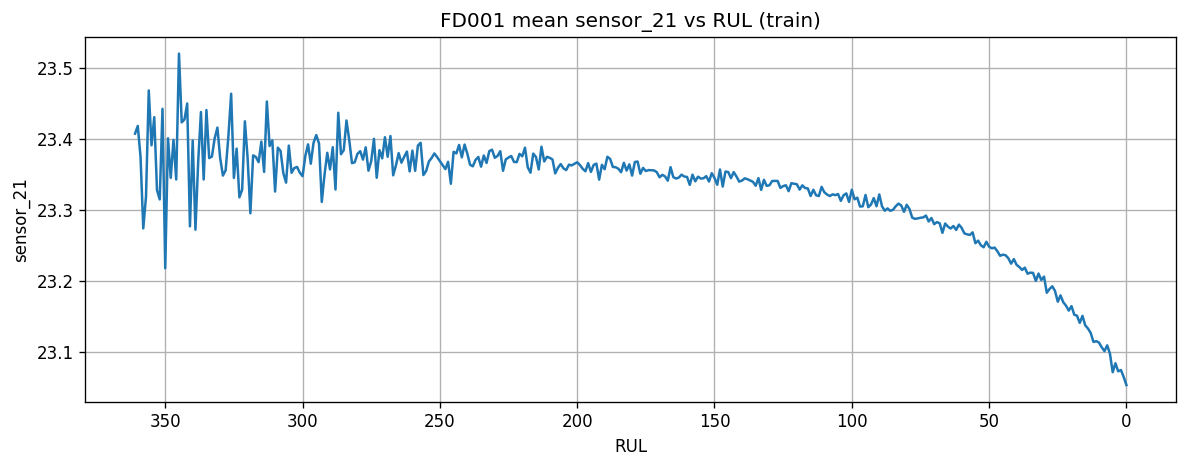

In [8]:
focus_sensors = top_sensors[:6]
agg = train_rul_df.groupby('rul')[focus_sensors].mean().sort_index(ascending=False)

for sensor in focus_sensors:
    plt.figure(figsize=(10, 4))
    plt.plot(agg.index, agg[sensor])
    plt.gca().invert_xaxis()
    plt.title(f'{FD} mean {sensor} vs RUL (train)')
    plt.xlabel('RUL')
    plt.ylabel(sensor)
    plt.tight_layout()
    plt.show()


## 6) Healthy vs late-life comparison

This compares early-life engine behavior with near-failure behavior in the train set.

,sensor,early_mean,late_mean,delta_late_minus_early
3,sensor_7,554.077551,552.150700,-1.926851
2,sensor_12,522.021909,520.375776,-1.646133
6,sensor_20,38.952314,38.578354,-0.373960
5,sensor_21,23.374802,23.145621,-0.229180
4,sensor_15,8.413356,8.492987,0.079632
0,sensor_11,47.316723,47.931454,0.614731
7,sensor_2,642.313970,643.318978,1.005009
1,sensor_4,1401.371453,1421.731776,20.360323


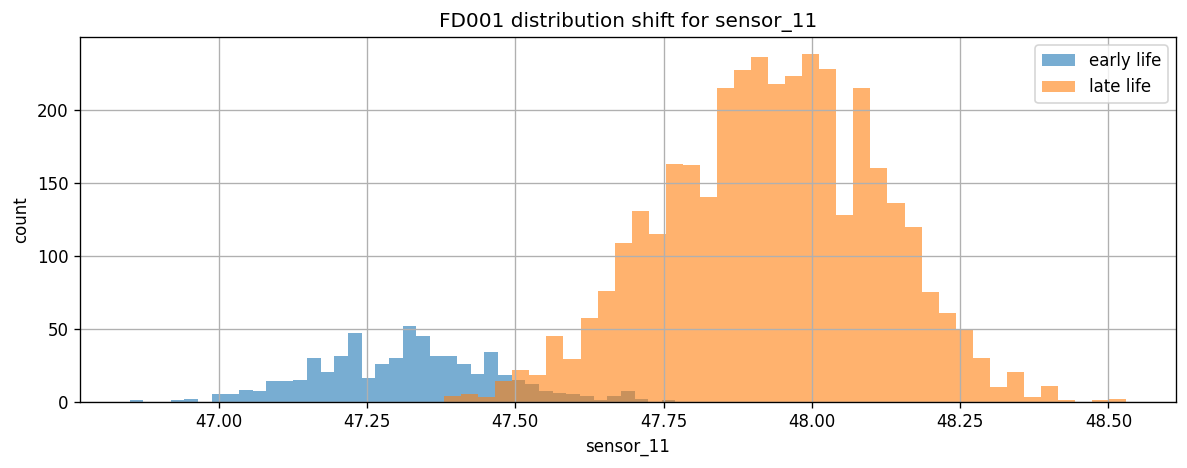

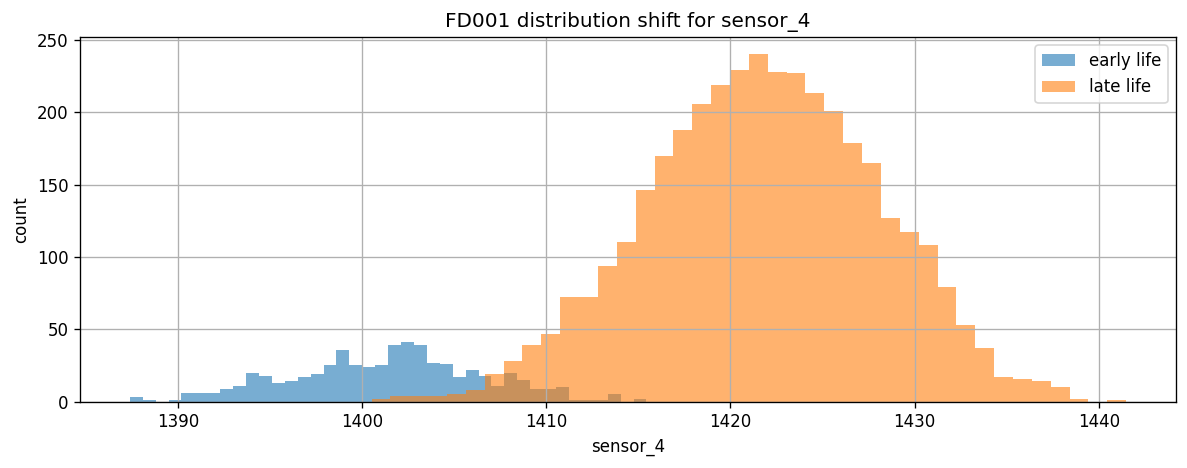

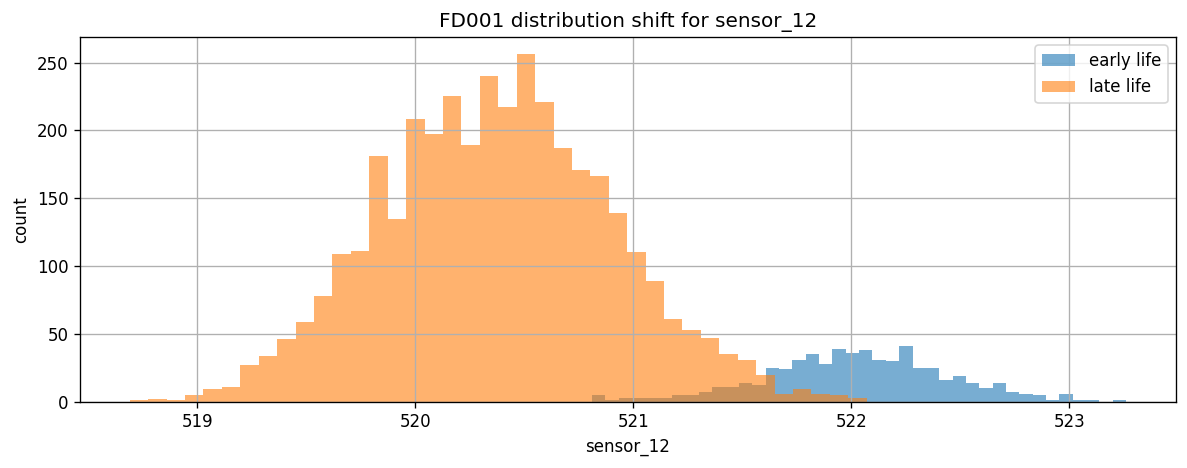

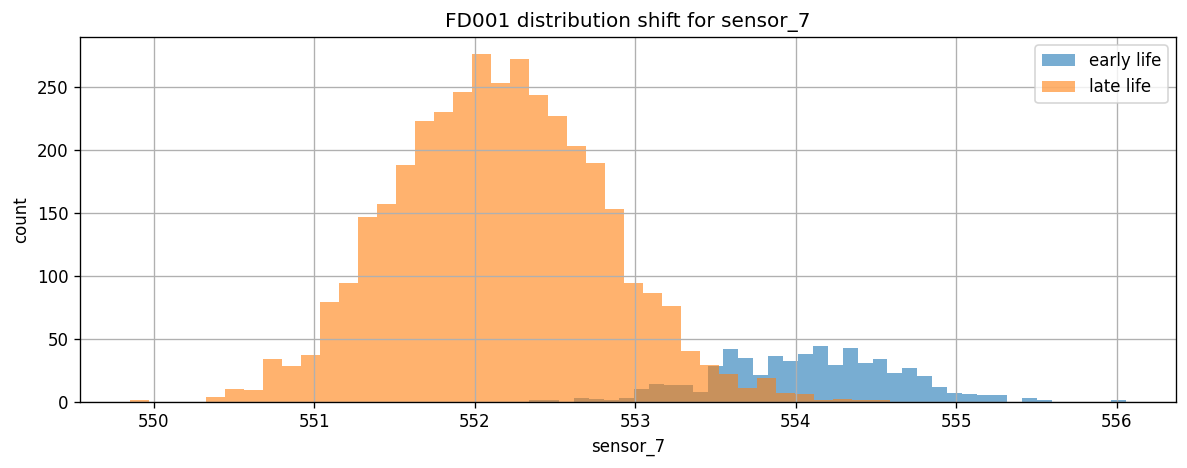

In [9]:
max_rul = train_rul_df['rul'].max()
early = train_rul_df[train_rul_df['rul'] >= max_rul * 0.7]
late = train_rul_df[train_rul_df['rul'] <= max(20, max_rul * 0.1)]

comparison_rows = []
for sensor in top_sensors[:10]:
    comparison_rows.append({
        'sensor': sensor,
        'early_mean': early[sensor].mean(),
        'late_mean': late[sensor].mean(),
        'delta_late_minus_early': late[sensor].mean() - early[sensor].mean(),
    })
comparison_df = pd.DataFrame(comparison_rows).sort_values('delta_late_minus_early')
display(comparison_df)

for sensor in top_sensors[:4]:
    plt.figure(figsize=(10, 4))
    plt.hist(early[sensor], bins=40, alpha=0.6, label='early life')
    plt.hist(late[sensor], bins=40, alpha=0.6, label='late life')
    plt.title(f'{FD} distribution shift for {sensor}')
    plt.xlabel(sensor)
    plt.ylabel('count')
    plt.legend()
    plt.tight_layout()
    plt.show()


## 7) Correlation heatmap for informative sensors

Use this to identify redundant sensors and groups that move together.

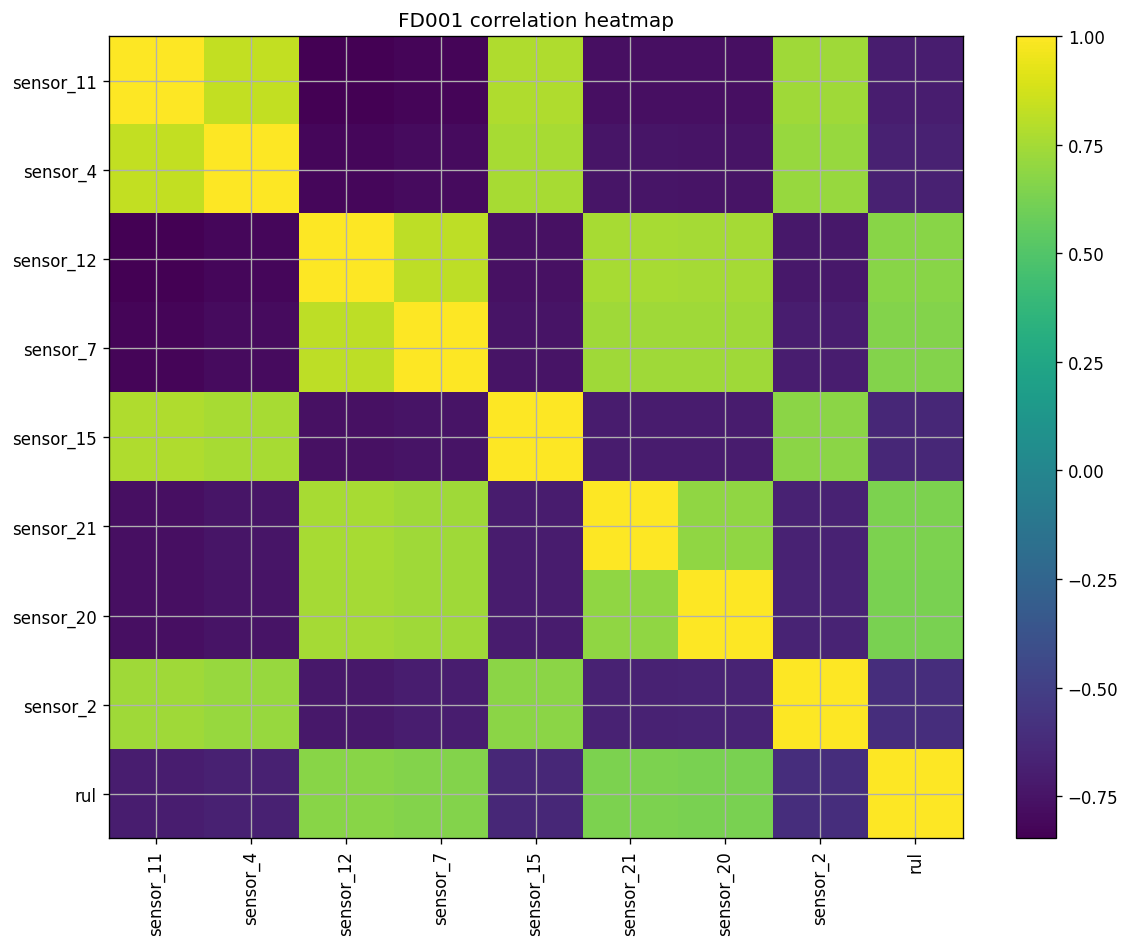

In [10]:
heatmap_sensors = top_sensors[:10]
corr = train_rul_df[heatmap_sensors + ['rul']].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title(f'{FD} correlation heatmap')
plt.colorbar()
plt.tight_layout()
plt.show()


## 8) Standardized engine heatmaps

These are especially useful for seeing when a sensor drifts during the life of a single engine.

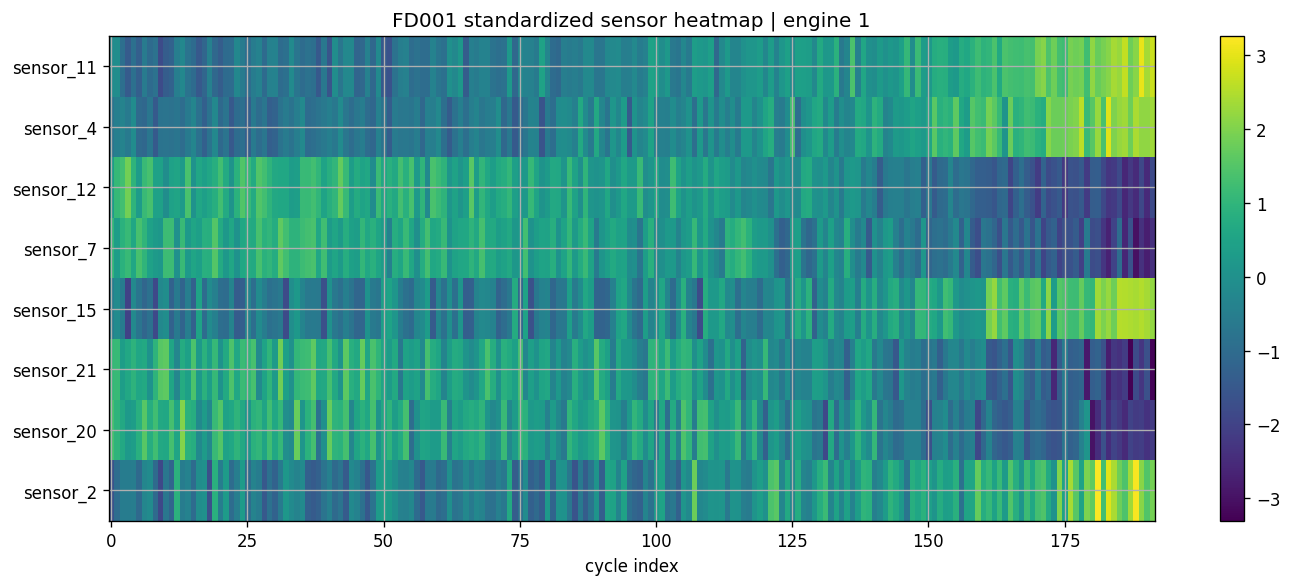

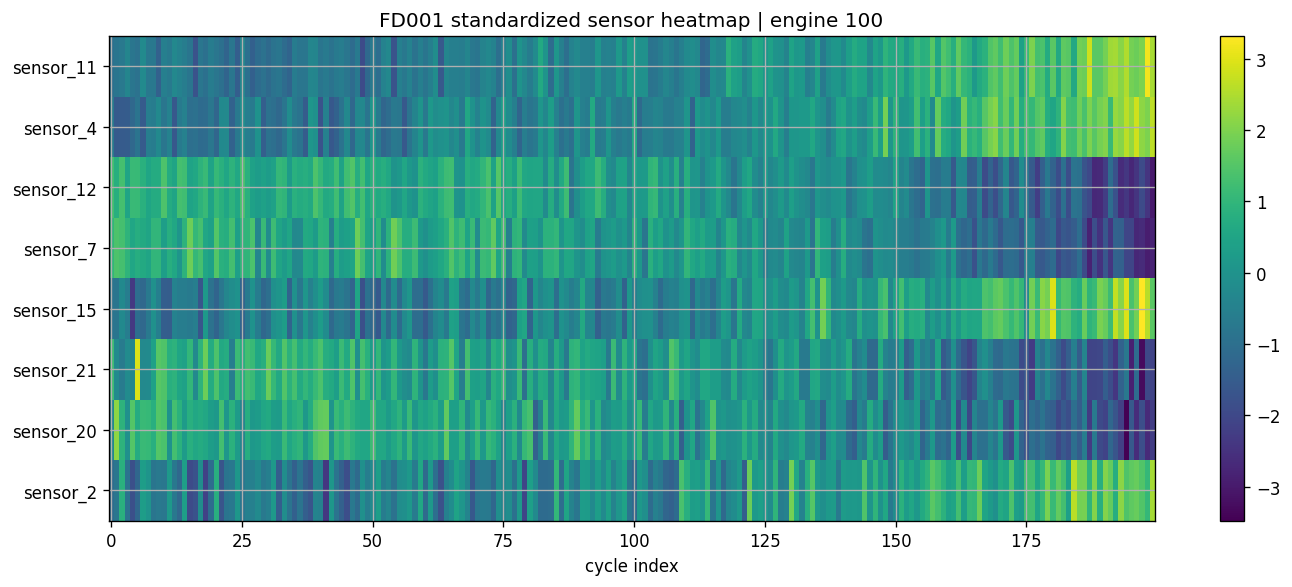

In [11]:
units = sample_units(train_rul_df, 2)
for unit in units:
    sub = train_rul_df[train_rul_df['unit'] == unit][['cycle'] + top_sensors[:8]].copy()
    scaled = zscore_per_column(sub, top_sensors[:8])
    matrix = scaled[top_sensors[:8]].to_numpy().T

    plt.figure(figsize=(12, 5))
    plt.imshow(matrix, aspect='auto')
    plt.yticks(range(len(top_sensors[:8])), top_sensors[:8])
    plt.xlabel('cycle index')
    plt.title(f'{FD} standardized sensor heatmap | engine {unit}')
    plt.colorbar()
    plt.tight_layout()
    plt.show()


## 9) Condition-normalized degradation view

For multi-condition datasets, raw sensor values mix degradation with operating-condition effects. The block below normalizes each sensor within operating-condition groups before plotting vs RUL.

,condition_id,rows
0,0.0|-0.0|100.0,5115
1,-0.0|0.0|100.0,5090
2,0.0|0.0|100.0,5028
3,-0.0|-0.0|100.0,4990
4,-0.01|-0.0|100.0,116
5,0.01|0.0|100.0,109
6,-0.01|0.0|100.0,98
7,0.01|-0.0|100.0,85


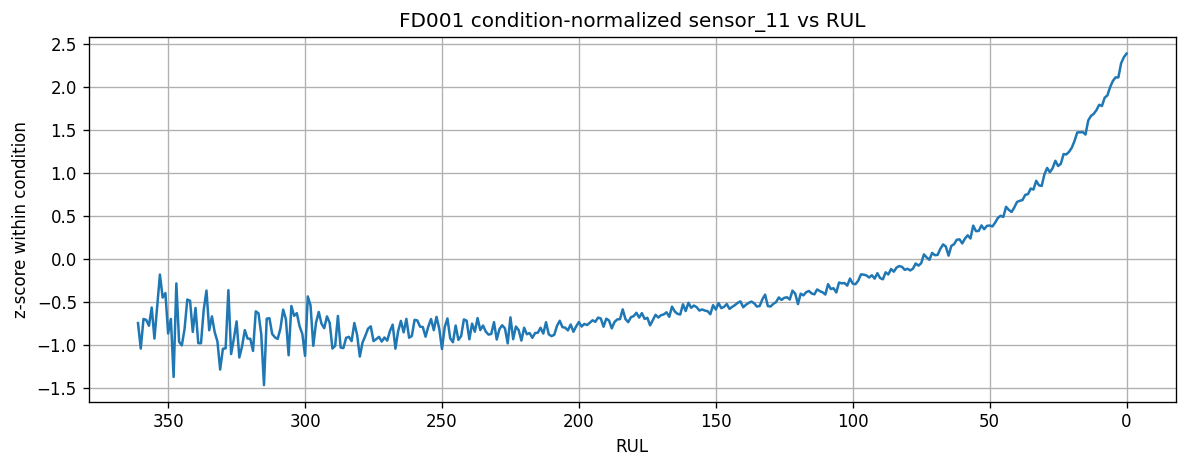

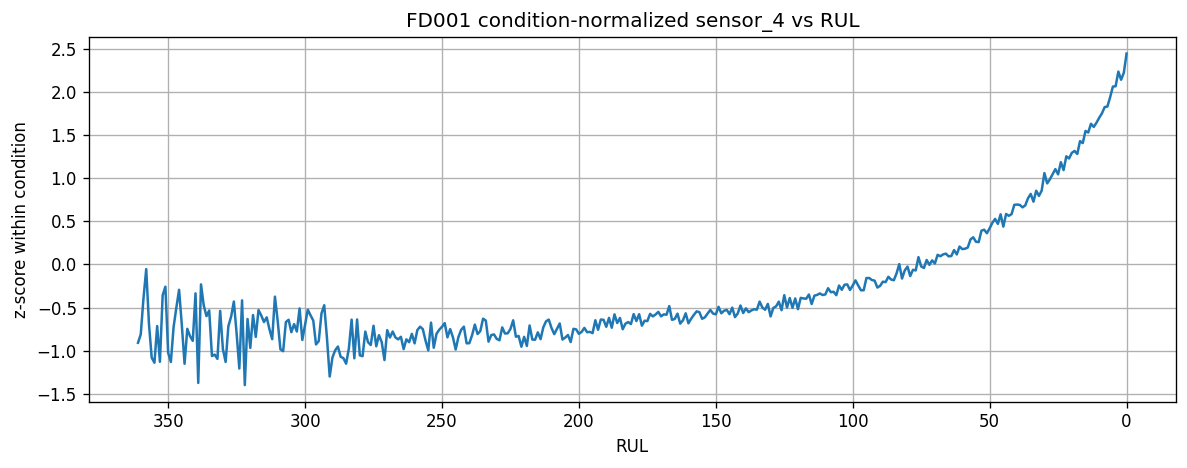

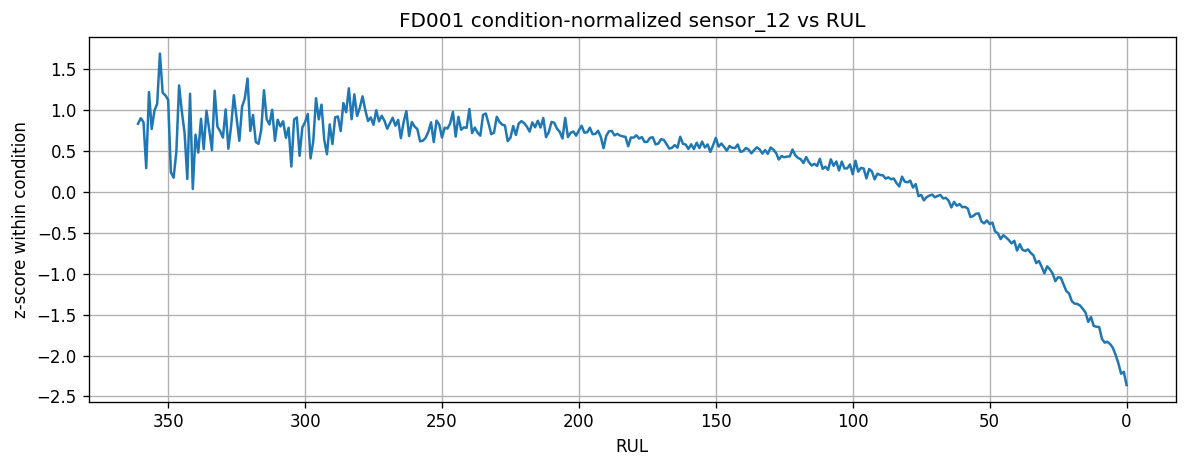

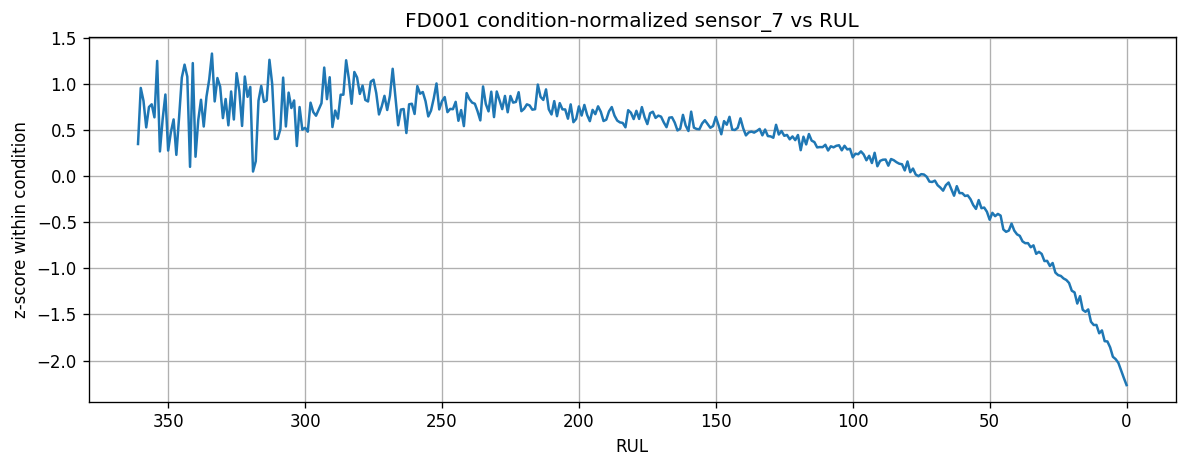

In [12]:
cond_df = train_rul_df.copy()
cond_df['condition_id'] = cond_df[OP_COLS].round(2).astype(str).agg('|'.join, axis=1)
condition_counts = cond_df['condition_id'].value_counts().rename_axis('condition_id').reset_index(name='rows')
display(condition_counts.head(10))

cond_norm = cond_df.copy()
for sensor in top_sensors[:6]:
    grp = cond_norm.groupby('condition_id')[sensor]
    mu = grp.transform('mean')
    sd = grp.transform('std').replace(0, 1)
    cond_norm[sensor + '_cond_z'] = (cond_norm[sensor] - mu) / sd

agg_cond = cond_norm.groupby('rul')[[s + '_cond_z' for s in top_sensors[:6]]].mean().sort_index(ascending=False)

for sensor in top_sensors[:4]:
    col = sensor + '_cond_z'
    plt.figure(figsize=(10, 4))
    plt.plot(agg_cond.index, agg_cond[col])
    plt.gca().invert_xaxis()
    plt.title(f'{FD} condition-normalized {sensor} vs RUL')
    plt.xlabel('RUL')
    plt.ylabel('z-score within condition')
    plt.tight_layout()
    plt.show()


## 10) Test-set view with true terminal RUL labels

Each test engine stops before failure. This plot uses the provided truth file to recover the true RUL at each observed cycle.

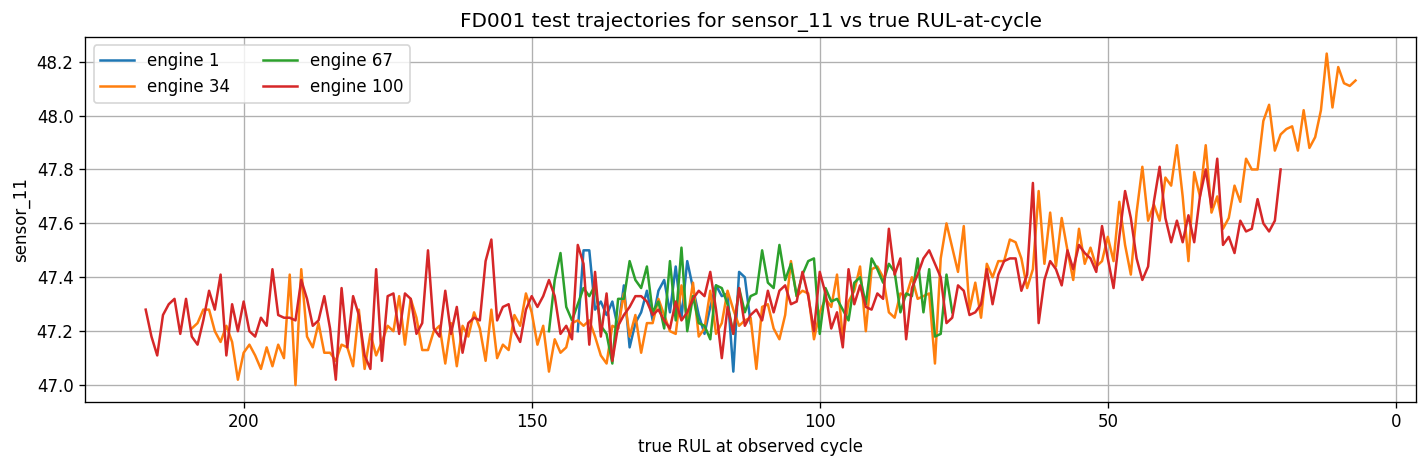

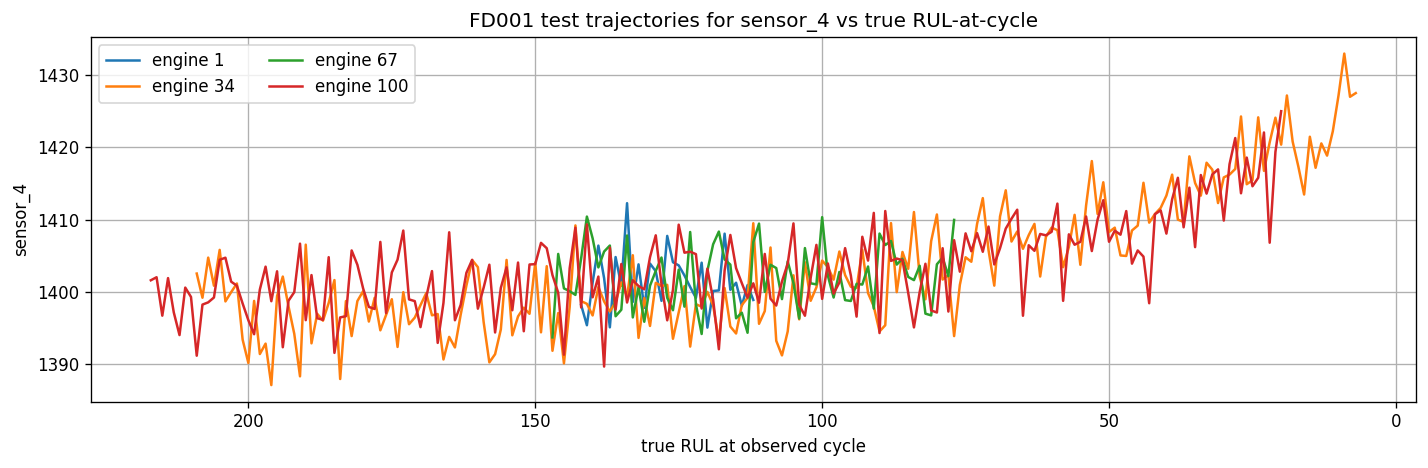

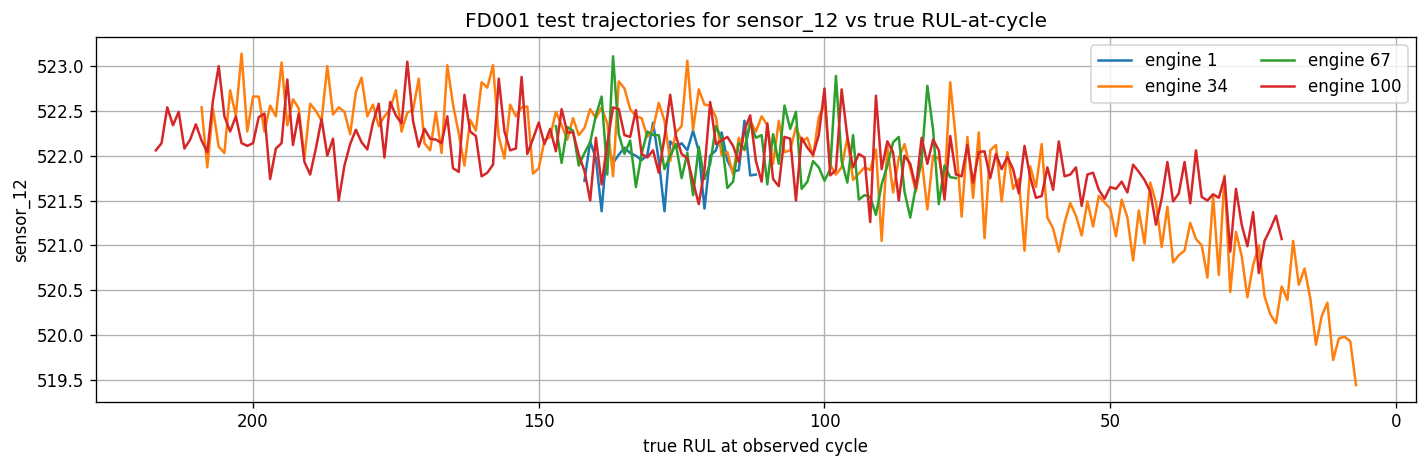

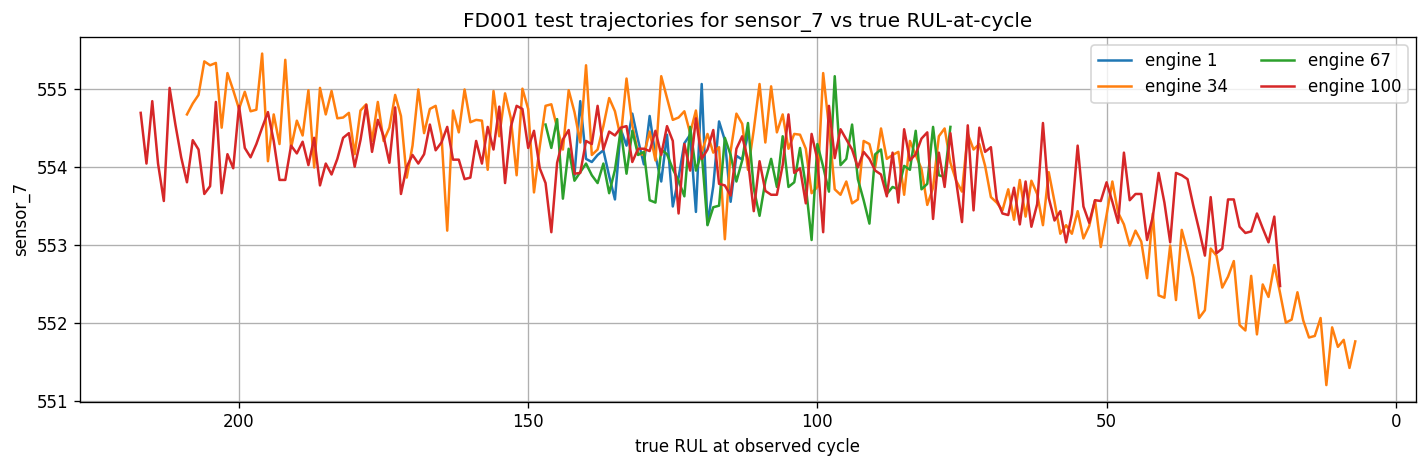

In [13]:
test_units = sample_units(test_rul_df, SAMPLE_ENGINES)
for sensor in top_sensors[:4]:
    plt.figure(figsize=(12, 4))
    for unit in test_units:
        sub = test_rul_df[test_rul_df['unit'] == unit]
        plt.plot(sub['rul_at_cycle'], sub[sensor], label=f'engine {unit}')
    plt.gca().invert_xaxis()
    plt.title(f'{FD} test trajectories for {sensor} vs true RUL-at-cycle')
    plt.xlabel('true RUL at observed cycle')
    plt.ylabel(sensor)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


## 11) Feature shortlist for modeling

This final table gives a compact shortlist of informative sensors for downstream anomaly, classification, and prognostics agents.

In [14]:
feature_shortlist = sensor_summary.loc[
    (~sensor_summary['near_constant']) & sensor_summary['abs_corr_with_rul'].notna(),
    ['sensor', 'std', 'corr_with_rul', 'abs_corr_with_rul', 'nunique']
].sort_values('abs_corr_with_rul', ascending=False)

display(feature_shortlist.head(15))


,sensor,std,corr_with_rul,abs_corr_with_rul,nunique
10,sensor_11,0.267087,-0.696228,0.696228,159
3,sensor_4,9.000605,-0.678948,0.678948,4051
11,sensor_12,0.737553,0.671983,0.671983,427
6,sensor_7,0.885092,0.657223,0.657223,513
14,sensor_15,0.037505,-0.642667,0.642667,1918
20,sensor_21,0.108251,0.635662,0.635662,4745
19,sensor_20,0.180746,0.629428,0.629428,120
1,sensor_2,0.500053,-0.606484,0.606484,310
16,sensor_17,1.548763,-0.606154,0.606154,13
2,sensor_3,6.131150,-0.584520,0.584520,3012
